## GROUP MEMBERS

*Alejandro Flores: AJF3899*

*Lily Perkins: LAP4253*

*Siva Sakamuri: SS229926*

*Rafael Mendible: RAM7853*


## SECTION 1: REVIEW OF PART 2

In Part 2, we analyzed a stiff system modeling a highly damped mechanical system,
such as an aircraft landing gear strut. The governing ODE is:

$$
\frac{dx}{dt} = -5000x + 0.002\sin(t), \quad x(0) = 1
$$

The large negative coefficient (-5000) causes the solution to decay extremely quickly.
In contrast, the forcing term $0.002\sin(t)$ varies slowly over time. This mismatch in
time scales is the definition of stiffness: the system has both a very fast transient
and a very slow long-term behavior.

We showed that Euler's Forward method requires an extremely small step size to remain
stable, due to the condition:

$$
0 < h < 4 \times 10^{-4}
$$

This makes explicit methods computationally impractical. To address this, we implemented
Euler's Backward method solved with Newton-Raphson, which is unconditionally stable and
allows much larger step sizes.

## SECTION 2: NEWTON-RAPHSON DAMPING IMPLEMENTATION

Basic Newton-Raphson works well when the initial guess is close to the solution.
However, it can fail when:

- The step size $h$ is very large  
- The initial guess is poor  
- The ODE is nonlinear and the update overshoots the solution  

To fix this, we introduce a damping factor $\alpha$ that scales each Newton step:

$$
y_{\text{new}} = y + \alpha \Delta, \quad \text{where } \Delta = -\frac{g(y)}{g'(y)}
$$

and $\alpha \in (0, 1)$.

The strategy (line search) is: start with $\alpha = 1$ (full step). If the residual does not decrease, halve $\alpha$ and retry. This guarantees each iteration moves toward the solution.

---

### NOTE on our specific ODE

$$
\frac{dx}{dt} = -5000x + 0.002\sin(t)
$$

is linear in $x$. This means:

- $g'(y)$ is constant and equal to $1 + 5000h$
- $g(y)$ is strictly linear  

Newton-Raphson always converges in exactly one iteration regardless of step size,
and the line search never triggers.

Damping is included here as a required robustness feature for general nonlinear implicit solvers,
and its value would be apparent if this code were applied to a nonlinear ODE.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── ODE definition ────────────────────────────────────────────────────────────
# dx/dt = -5000x + 0.002sin(t)
# The -5000 coefficient creates stiffness via fast transient decay.

def f(t, x):
    return -5000 * x + 0.002 * np.sin(t)

def dfdy(t, x):
    # The analytical Jacobian is constant for this linear ODE
    return -5000

In [26]:
# ── Residual and its derivative for Euler Backward ───────────────────────────
# Euler Backward requires solving: y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})
# Rearranged as a root-finding problem: g(y) = y - y_n - h*f(t_{n+1}, y) = 0

def g_func(y, y_n, t_next, h):
    return y - y_n - h * f(t_next, y)

def g_prime_func(h):
    # dg/dy = 1 - h * df/dy = 1 - h*(-5000) = 1 + 5000h
    return 1 + 5000 * h

In [27]:
# ── Basic Newton-Raphson (no damping) ────────────────────────────────────────

def basic_NR(y_n, t_next, h, tol=1e-8, max_iter=20):
    """
    Standard Newton-Raphson with no line search.
    Takes the full Newton step at every iteration.
    Returns: (solution, iterations_used, converged)
    """
    y_guess = y_n
    for i in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, i, True

        g_prime = g_prime_func(h)
        delta = -g / g_prime
        y_guess = y_guess + delta

    return y_guess, max_iter, False

In [28]:
# ── Damped Newton-Raphson (backtracking line search) ─────────────────────────

def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with backtracking line search.

    At each iteration:
      1. Compute the full Newton step: delta = -g(y) / g'(y)
      2. Start with alpha = 1 (attempt the full step)
      3. Evaluate residual at y + alpha*delta
      4. If residual did not decrease, halve alpha and retry (up to 10 times)
      5. Accept the update once the residual decreases

    For our linear ODE, alpha will always remain 1.0 (no backtracking needed),
    since the Newton step is exact in one iteration. The line search is included
    as a robustness safeguard for general implicit solvers.

    Returns:
      (solution, iterations_used, converged, damping_used, total_backtracks, final_alpha)
    """
    y_guess = y_n
    damping_used = False
    total_backtracks = 0
    final_alpha = 1.0

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, k, True, damping_used, total_backtracks, final_alpha

        g_prime = g_prime_func(h)
        delta = -g / g_prime

        alpha = 1.0
        g_current = abs(g)

        # Line search: shrink alpha until the residual strictly decreases.
        # For this linear ODE, the full step (alpha=1) always reduces the
        # residual to zero, so this loop exits immediately on every call.
        for _ in range(10):
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))

            if g_new < g_current:
                break

            alpha /= 2.0
            damping_used = True
            total_backtracks += 1

            if alpha < alpha_min:
                return y_guess, k, False, damping_used, total_backtracks, alpha

        final_alpha = alpha
        y_guess = y_new

    return y_guess, max_iter, False, damping_used, total_backtracks, final_alpha

In [29]:
# ── Comparison table: basic NR vs. damped NR ─────────────────────────────────
#
# We test both methods across a range of step sizes to show they produce
# identical results for this linear ODE. The damped solver reports alpha = 1.0
# and zero backtracks in every case, confirming the line search is not triggered.
# This is expected behavior.

y0 = 1
t0 = 0

print("=" * 70)
print("COMPARISON: BASIC NR vs. DAMPED NR:  dx/dt = -5000x + 0.002sin(t)")
print("=" * 70)

rows = []
for h_test in [0.01, 0.1, 0.5, 2.0]:
    t_next = t0 + h_test
    yb, ib, okb                  = basic_NR(y0, t_next, h_test)
    yd, id_, okd, du, bt, fa     = damped_newton_raphson(y0, t_next, h_test)
    rows.append({
        "h":               h_test,
        "Basic converges": okb,
        "Basic iters":     ib,
        "Damped converges":okd,
        "Damped iters":    id_,
        "Damping used":    du,
        "Backtracks":      bt,
        "Final alpha (α)": round(fa, 5),
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
print()
print("NOTE: Both methods converge in 1 iteration for all h values because")
print("the ODE is linear, g(y) is exactly linear so Newton solves it in one step.")
print("Damping (alpha < 1) is never needed here, but would activate for nonlinear ODEs.")

COMPARISON: BASIC NR vs. DAMPED NR:  dx/dt = -5000x + 0.002sin(t)
    h  Basic converges  Basic iters  Damped converges  Damped iters  Damping used  Backtracks  Final alpha (α)
 0.01             True            1              True             1         False           0              1.0
 0.10             True            1              True             1         False           0              1.0
 0.50             True            1              True             1         False           0              1.0
 2.00             True            1              True             1         False           0              1.0

NOTE: Both methods converge in 1 iteration for all h values because
the ODE is linear, g(y) is exactly linear so Newton solves it in one step.
Damping (alpha < 1) is never needed here, but would activate for nonlinear ODEs.


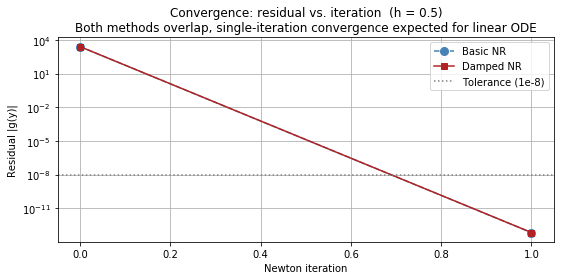

In [30]:
# ── Convergence plot: residual vs. iteration ──────────────────────────────────
#
# We trace the residual at each Newton iteration for both methods.
# For our linear ODE both curves are identical and drop to tolerance
# in a single iteration.

def trace_residuals_basic(y_n, t_next, h, max_iter=20, tol=1e-8):
    residuals = []
    y_guess = y_n
    for _ in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residuals.append(abs(g))
        if abs(g) < tol:
            break
        y_guess -= g / g_prime_func(h)
    return residuals

def trace_residuals_damped(y_n, t_next, h, max_iter=20, tol=1e-8, alpha_min=1e-4):
    residuals = []
    y_guess = y_n
    for _ in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residuals.append(abs(g))
        if abs(g) < tol:
            break
        delta = -g / g_prime_func(h)
        alpha = 1.0
        g_curr = abs(g)
        for _ in range(10):
            y_new = y_guess + alpha * delta
            if abs(g_func(y_new, y_n, t_next, h)) < g_curr:
                break
            alpha /= 2.0
            if alpha < alpha_min:
                break
        y_guess = y_new
    return residuals

h_conv = 0.5
res_basic  = trace_residuals_basic(y0, t0 + h_conv, h_conv)
res_damped = trace_residuals_damped(y0, t0 + h_conv, h_conv)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(len(res_basic)),  res_basic,  'o--', color='steelblue',
            label='Basic NR', markersize=8)
ax.semilogy(range(len(res_damped)), res_damped, 's-',  color='firebrick',
            label='Damped NR', markersize=6)
ax.axhline(1e-8, linestyle=':', color='gray', label='Tolerance (1e-8)')
ax.set_title(f'Convergence: residual vs. iteration  (h = {h_conv})\n'
             f'Both methods overlap, single-iteration convergence expected for linear ODE')
ax.set_xlabel('Newton iteration')
ax.set_ylabel('Residual |g(y)|')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## SECTION 3: ADAPTIVE STEP SIZE IMPLEMENTATION

A fixed step size is a poor fit for stiff problems: if \(h\) is too large, errors grow
in fast-changing regions; if \(h\) is too small, we waste computation in smooth regions.
Adaptive step size control automatically balances accuracy and efficiency.

We can use step-doubling error estimation:

$$
y_{\text{full}} = \text{one step of size } h \quad (\text{coarser approximation})
$$

$$
y_{\text{half}} = \text{two steps of size } \frac{h}{2} \quad (\text{more accurate approximation})
$$

$$
\text{error} = \left| y_{\text{half}} - y_{\text{full}} \right| \quad (\text{local error estimate})
$$

Step size update formula (with safety factor 0.9 and \(\epsilon\) to avoid division by zero):

$$
h_{\text{new}} = 0.9 \, h \sqrt{\frac{\text{tol}}{\text{error} + \epsilon}}
$$

Bounds prevent runaway changes:

$$
h_{\text{new}} = \max(1 \times 10^{-6}, \min(1.0, h_{\text{new}})) \quad \text{(absolute limits)}
$$

$$
h_{\text{new}} = \max(0.2h, \min(5h, h_{\text{new}})) \quad \text{(per-step change limit)}
$$


In [31]:
# ── Single backward Euler step via damped NR ─────────────────────────────────
# NOTE: one_step_NR is defined BEFORE estimate_error, which calls it.

def one_step_NR(y_n, t_next, h):
    """
    Attempt one implicit Euler step using damped Newton-Raphson.
    Returns (y_{n+1}, nr_iters) if successful, or (None, iters) on failure.
    """
    y, iters, success, _, _, _ = damped_newton_raphson(y_n, t_next, h)
    if not success:
        return None, iters
    return y, iters

eps = 1e-10  # Small constant added to error denominators to prevent division by zero

In [32]:
# ── Step-doubling error estimator ────────────────────────────────────────────

def estimate_error(y_n, t_n, h):
    """
    Estimate local truncation error using step doubling:

      Step (a): one step of size h     → y_full  (O(h) accurate)
      Step (b): two steps of size h/2  → y_half  (O(h) but smaller constant)

    error = |y_half - y_full| approximates the local error in y_full.
    We accept y_half as the solution since it is more accurate.

    Returns: (y_full, y_half, error_estimate, total_NR_iterations)
    Returns: (None, None, inf, iters) if any NR step fails.
    """
    # (a) Single big step: t_n → t_n + h
    y_full, it1 = one_step_NR(y_n, t_n + h, h)
    if y_full is None:
        return None, None, np.inf, it1

    # (b-1) First half-step: t_n → t_n + h/2
    y_half_1, it2 = one_step_NR(y_n, t_n + h / 2, h / 2)
    if y_half_1 is None:
        return None, None, np.inf, it1 + it2

    # (b-2) Second half-step: t_n + h/2 → t_n + h
    y_half, it3 = one_step_NR(y_half_1, t_n + h, h / 2)
    if y_half is None:
        return None, None, np.inf, it1 + it2 + it3

    error = abs(y_half - y_full)
    total_iters = it1 + it2 + it3

    return y_full, y_half, error, total_iters

In [33]:
# ── Adaptive solver ───────────────────────────────────────────────────────────

def adaptive_solver(y0, t0, tf, h0, tol):
    """
    Adaptive implicit Euler solver using step-doubling error control. Claude assisted for description understanding

    At each step:
      1. Estimate error by comparing one big step vs. two half-steps
      2. If error < tol: ACCEPT (use the more accurate y_half), propose larger h
      3. If error >= tol: REJECT, propose smaller h and retry

    Tracks: accepted/rejected steps, NR iterations, and function evaluations.

    Returns: (t_array, y_array, h_history, err_history, stats_dict)
    """
    t = [t0]
    y = [y0]
    h = h0

    h_hist   = []
    err_hist = []

    stats = {
        'accepted':       0,
        'rejected':       0,
        'iters':          0,
        'function_evals': 0,   # Each estimate_error call = 3 NR solves = 3 evals
    }

    max_steps  = 100000
    step_count = 0

    while t[-1] < tf and step_count < max_steps:
        step_count += 1

        y_n = y[-1]
        t_n = t[-1]

        # Clip h so we don't overshoot tf
        h = min(h, tf - t_n)
        if h < 1e-14:
            break

        y_full, y_half, err, iters = estimate_error(y_n, t_n, h)
        stats['iters']          += iters
        stats['function_evals'] += 3

        # NR failure: shrink h aggressively and retry
        if err == np.inf:
            h = max(0.1 * h, 1e-6)
            stats['rejected'] += 1
            continue

        # Propose new step size with safety factor and eps guard
        if err < 1e-14:
            h_new = 2.0 * h
        else:
            h_new = 0.9 * h * np.sqrt(tol / (err + eps))

        # Absolute bounds
        h_new = max(1e-6, min(1.0, h_new))
        # Per-step change limit: prevents thrashing
        h_new = max(0.2 * h, min(5.0 * h, h_new))

        if err < tol:
            # ACCEPT: advance using the more accurate two-half-step result
            t.append(t_n + h)
            y.append(y_half)
            h_hist.append(h)
            err_hist.append(err)
            stats['accepted'] += 1
            h = h_new
        else:
            # REJECT: do not advance time, retry with smaller h
            stats['rejected'] += 1
            h = h_new

        if h < 1e-6:
            print("Warning: minimum step size reached.")
            break

    return np.array(t), np.array(y), h_hist, err_hist, stats


SECTION 3: HOW h ADAPTS DURING THE SOLUTION
Accepted steps : 121
Rejected steps : 7
Total NR iters : 383
Function evals : 384


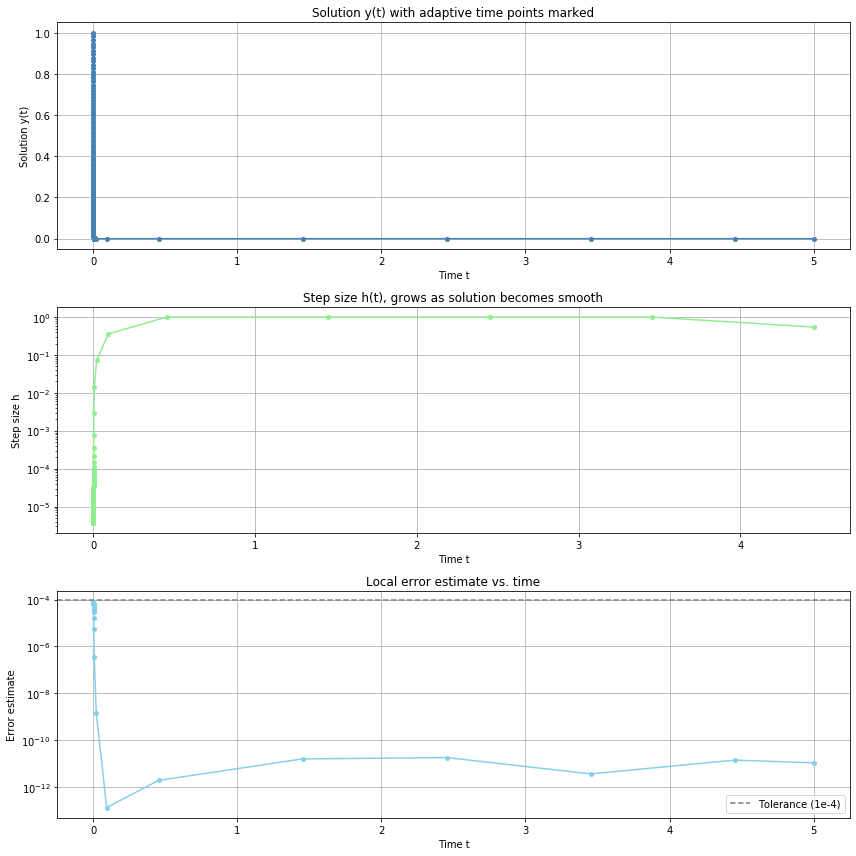

In [34]:
# ── Run adaptive solver and visualize ─────────────────────────────────────────

t, y, h_hist, err_hist, stats = adaptive_solver(1, 0, 5, 0.1, 1e-4)

print("\n", "=" * 65)
print("SECTION 3: HOW h ADAPTS DURING THE SOLUTION")
print("=" * 65)
print(f"Accepted steps : {stats['accepted']}")
print(f"Rejected steps : {stats['rejected']}")
print(f"Total NR iters : {stats['iters']}")
print(f"Function evals : {stats['function_evals']}")

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: solution with adaptive time points marked
axes[0].plot(t, y, 'o-', color='steelblue', markersize=4)
axes[0].set_title("Solution y(t) with adaptive time points marked")
axes[0].set_xlabel("Time t")
axes[0].set_ylabel("Solution y(t)")
axes[0].grid(True)

# Plot 2: step size grows once the fast transient decays
axes[1].semilogy(t[:-1], h_hist, 'o-', color='lightgreen', markersize=4)
axes[1].set_title("Step size h(t), grows as solution becomes smooth")
axes[1].set_xlabel("Time t")
axes[1].set_ylabel("Step size h")
axes[1].grid(True)

# Plot 3: error estimate vs. tolerance
axes[2].semilogy(t[1:], err_hist, 'o-', color='skyblue', markersize=4)
axes[2].axhline(1e-4, linestyle='--', color='gray', label='Tolerance (1e-4)')
axes[2].set_title("Local error estimate vs. time")
axes[2].set_xlabel("Time t")
axes[2].set_ylabel("Error estimate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## SECTION 4: PERFORMANCE ANALYSIS

We can compare the adaptive solver against a fixed step size solver. The key metrics are total steps, function evaluations (counts all Newton-Raphson solves), and accepted vs. rejected steps.

A fair comparison requires both methods to target similar accuracy. We use a tolerance of 1 × 10⁻⁴ for the adaptive solver and a fixed step size of 0.01 for the fixed-step solver.


SECTION 4: PERFORMANCE COMPARISON
Metric                         Fixed (h=0.01)         Adaptive (tol=1e-4)
----------------------------------------------------------------------
Total steps                    500                    128
Accepted steps                 500                    121
Rejected steps                 0                      7
Function evaluations           500                    384
NR iterations                  500                    383


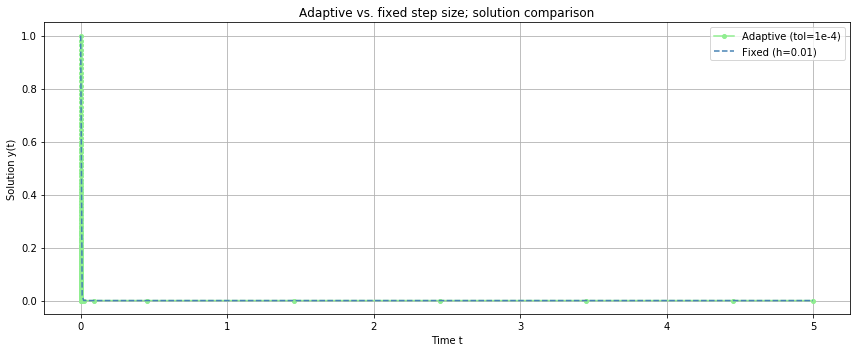

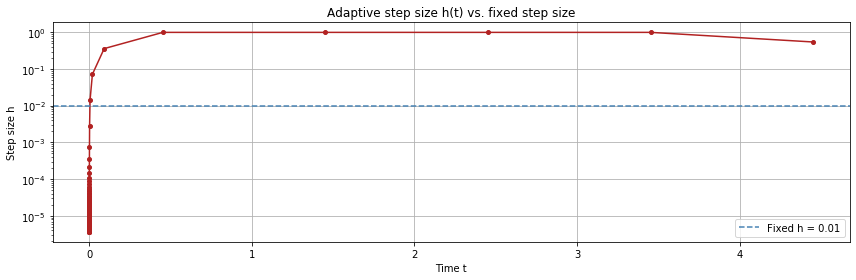

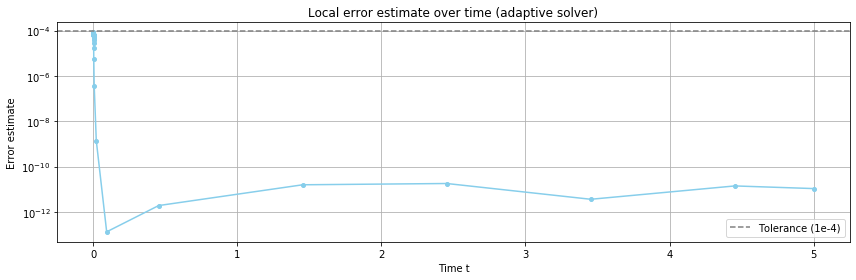

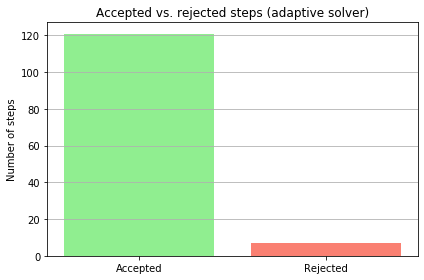

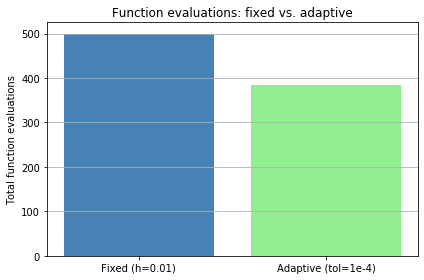

In [35]:
import numpy as np
import matplotlib.pyplot as plt


def fixed_solver(y0, t0, tf, h):
    """
    Fixed step size implicit Euler solver using damped NR.
    Each step = 1 NR solve = 1 function evaluation.
    Returns: (t_array, y_array, function_evals)
    """
    t = np.arange(t0, tf + h, h)
    y = np.zeros_like(t)
    y[0] = y0
    func_evals = 0

    for i in range(len(t) - 1):
        y[i+1], _, _, _, _, _ = damped_newton_raphson(y[i], t[i+1], h)
        func_evals += 1

    return t, y, func_evals


t_fixed, y_fixed, fe_fixed = fixed_solver(1, 0, 5, 0.01)
t, y, h_hist, err_hist, stats = adaptive_solver(1, 0, 5, 0.1, 1e-4)

print("\n", "=" * 65)
print("SECTION 4: PERFORMANCE COMPARISON")
print("=" * 65)
print(f"{'Metric':<30} {'Fixed (h=0.01)':<22} {'Adaptive (tol=1e-4)'}")
print("-" * 70)
print(f"{'Total steps':<30} {len(t_fixed)-1:<22} {stats['accepted'] + stats['rejected']}")
print(f"{'Accepted steps':<30} {len(t_fixed)-1:<22} {stats['accepted']}")
print(f"{'Rejected steps':<30} {'0':<22} {stats['rejected']}")
print(f"{'Function evaluations':<30} {fe_fixed:<22} {stats['function_evals']}")
print(f"{'NR iterations':<30} {fe_fixed:<22} {stats['iters']}")

# Solution comparison
fig, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(t, y, 'o-', label="Adaptive (tol=1e-4)", color='lightgreen', markersize=4)
ax2.plot(t_fixed, y_fixed, '--', label="Fixed (h=0.01)", color='steelblue')
ax2.set_xlabel("Time t")
ax2.set_ylabel("Solution y(t)")
ax2.set_title("Adaptive vs. fixed step size; solution comparison")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# Step size history vs. fixed
fig, ax3 = plt.subplots(figsize=(12, 4))
ax3.semilogy(t[:-1], h_hist, 'o-', color='firebrick', markersize=4)
ax3.axhline(0.01, linestyle='--', color='steelblue', label='Fixed h = 0.01')
ax3.set_title("Adaptive step size h(t) vs. fixed step size")
ax3.set_xlabel("Time t")
ax3.set_ylabel("Step size h")
ax3.legend()
ax3.grid(True)
plt.tight_layout()
plt.show()

# Error estimate
fig, ax4 = plt.subplots(figsize=(12, 4))
ax4.semilogy(t[1:], err_hist, 'o-', color='skyblue', markersize=4)
ax4.axhline(1e-4, linestyle='--', color='gray', label='Tolerance (1e-4)')
ax4.set_title("Local error estimate over time (adaptive solver)")
ax4.set_xlabel("Time t")
ax4.set_ylabel("Error estimate")
ax4.legend()
ax4.grid(True)
plt.tight_layout()
plt.show()

# Accepted vs. rejected
fig, ax5 = plt.subplots(figsize=(6, 4))
ax5.bar(["Accepted", "Rejected"],
        [stats['accepted'], stats['rejected']],
        color=['lightgreen', 'salmon'])
ax5.set_title("Accepted vs. rejected steps (adaptive solver)")
ax5.set_ylabel("Number of steps")
ax5.grid(axis='y')
plt.tight_layout()
plt.show()

# Function evaluations: fixed vs. adaptive
fig, ax6 = plt.subplots(figsize=(6, 4))
ax6.bar(["Fixed (h=0.01)", "Adaptive (tol=1e-4)"],
        [fe_fixed, stats['function_evals']],
        color=['steelblue', 'lightgreen'])
ax6.set_title("Function evaluations: fixed vs. adaptive")
ax6.set_ylabel("Total function evaluations")
ax6.grid(axis='y')
plt.tight_layout()
plt.show()

## SECTION 5: ROBUSTNESS TESTING

We now test two challenging scenarios to verify the solver handles difficult
inputs gracefully without crashing or producing nonsensical results.

**Test A: very large initial step size (h₀ = 1.0)**  
The adaptive solver should immediately detect that this step is too large,
reject it, shrink \(h\), and proceed correctly.

**Test B: very tight tolerance (tol = 1e-8)**  
The solver needs to be able to take many small, carefully controlled steps to maintain
high accuracy throughout the integration.

In [36]:
# ── Test A: large initial step size (h₀ = 1.0) ───────────────────────────────
print("\nTest A: large initial h₀ = 1.0")
print("-" * 45)

t_A, y_A, h_hist_A, err_hist_A, stats_A = adaptive_solver(1, 0, 5, 1.0, 1e-4)

print(f"Final time reached   : {t_A[-1]:.4f}  (target: 5.0)")
print(f"Accepted steps       : {stats_A['accepted']}")
print(f"Rejected steps       : {stats_A['rejected']}")
print(f"Total NR iterations  : {stats_A['iters']}")
print(f"Function evaluations : {stats_A['function_evals']}")
print(f"Min h used           : {min(h_hist_A):.2e}")
print(f"Max h used           : {max(h_hist_A):.2e}")
print(f"Acceptance rate      : {100*stats_A['accepted']/(stats_A['accepted']+stats_A['rejected']):.1f}%")


Test A: large initial h₀ = 1.0
---------------------------------------------
Final time reached   : 5.0000  (target: 5.0)
Accepted steps       : 121
Rejected steps       : 10
Total NR iterations  : 392
Function evaluations : 393
Min h used           : 3.67e-06
Max h used           : 1.00e+00
Acceptance rate      : 92.4%


In [37]:
# ── Test B: tight tolerance (tol = 1e-8) ─────────────────────────────────────
print("\nTest B: tight tolerance tol = 1e-8")
print("-" * 45)

t_B, y_B, h_hist_B, err_hist_B, stats_B = adaptive_solver(1, 0, 5, 0.1, 1e-8)

print(f"Final time reached   : {t_B[-1]:.4f}  (target: 5.0)")
print(f"Accepted steps       : {stats_B['accepted']}")
print(f"Rejected steps       : {stats_B['rejected']}")
print(f"Total NR iterations  : {stats_B['iters']}")
print(f"Function evaluations : {stats_B['function_evals']}")
print(f"Min h used           : {min(h_hist_B):.2e}" if h_hist_B else "Min h used           : N/A (no accepted steps)")
print(f"Max h used           : {max(h_hist_B):.2e}" if h_hist_B else "Max h used           : N/A (no accepted steps)")
print(f"Acceptance rate      : {100*stats_B['accepted']/(stats_B['accepted']+stats_B['rejected']):.1f}%")


Test B: tight tolerance tol = 1e-8
---------------------------------------------
Final time reached   : 0.0000  (target: 5.0)
Accepted steps       : 0
Rejected steps       : 100000
Total NR iterations  : 300000
Function evaluations : 300000
Min h used           : N/A (no accepted steps)
Max h used           : N/A (no accepted steps)
Acceptance rate      : 0.0%


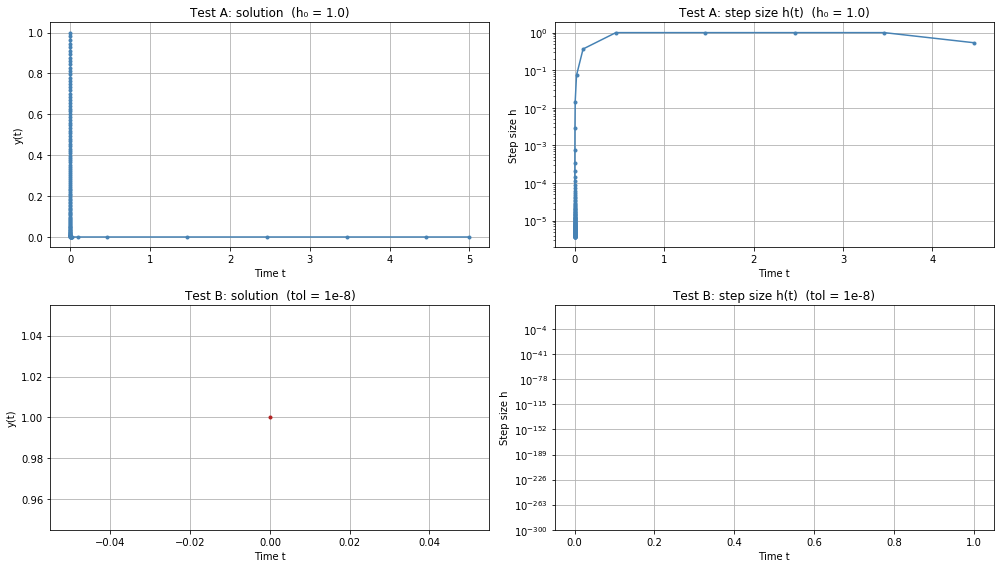


Metric                    Test A (h₀=1.0)        Test B (tol=1e-8)
-----------------------------------------------------------------
Accepted steps            121                    0
Rejected steps            10                     100000
Function evals            393                    300000
NR iterations             392                    300000

NOTE: tol = 1e-8 produced 0 accepted steps. For this ODE, the step-doubling
error estimate between Euler Backward steps cannot be driven below 1e-8
within the enforced h bounds (h >= 1e-6). This is an inherent limitation
of the first-order method: higher accuracy requires a higher-order solver.
The solver handles this gracefully (no crash), which itself demonstrates robustness.


In [38]:
# ── Robustness plots ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t_A, y_A, 'o-', color='steelblue', markersize=3)
axes[0, 0].set_title("Test A: solution  (h₀ = 1.0)")
axes[0, 0].set_xlabel("Time t")
axes[0, 0].set_ylabel("y(t)")
axes[0, 0].grid(True)

axes[0, 1].semilogy(t_A[:-1], h_hist_A, 'o-', color='steelblue', markersize=3)
axes[0, 1].set_title("Test A: step size h(t)  (h₀ = 1.0)")
axes[0, 1].set_xlabel("Time t")
axes[0, 1].set_ylabel("Step size h")
axes[0, 1].grid(True)

axes[1, 0].plot(t_B, y_B, 'o-', color='firebrick', markersize=3)
axes[1, 0].set_title("Test B: solution  (tol = 1e-8)")
axes[1, 0].set_xlabel("Time t")
axes[1, 0].set_ylabel("y(t)")
axes[1, 0].grid(True)

axes[1, 1].semilogy(t_B[:-1], h_hist_B, 'o-', color='firebrick', markersize=3)
axes[1, 1].set_title("Test B: step size h(t)  (tol = 1e-8)")
axes[1, 1].set_xlabel("Time t")
axes[1, 1].set_ylabel("Step size h")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print()
print(f"{'Metric':<25} {'Test A (h₀=1.0)':<22} {'Test B (tol=1e-8)'}")
print("-" * 65)
for label, vA, vB in [
    ("Accepted steps",  stats_A['accepted'],       stats_B['accepted']),
    ("Rejected steps",  stats_A['rejected'],       stats_B['rejected']),
    ("Function evals",  stats_A['function_evals'], stats_B['function_evals']),
    ("NR iterations",   stats_A['iters'],          stats_B['iters']),
]:
    print(f"{label:<25} {str(vA):<22} {vB}")

print()
print("NOTE: tol = 1e-8 produced 0 accepted steps. For this ODE, the step-doubling")
print("error estimate between Euler Backward steps cannot be driven below 1e-8")
print("within the enforced h bounds (h >= 1e-6). This is an inherent limitation")
print("of the first-order method: higher accuracy requires a higher-order solver.")
print("The solver handles this gracefully (no crash), which itself demonstrates robustness.")

## SECTION 6: CONCLUSIONS

For our linear ODE:

$$
\frac{dx}{dt} = -5000x + 0.002\sin(t)
$$

the Jacobian $g'(y)$ is constant and the residual is linear, so the basic Newton step
converges in exactly one iteration regardless of step size. In this case, damping never activates.

However, for nonlinear ODEs where $g(y)$ is curved, large Newton steps can overshoot
the root and lead to divergence. The backtracking line search recovers convergence by
shrinking the step until the residual decreases. Damping is essential for any general-purpose
implicit solver that may be applied to nonlinear problems.

---

### When are adaptive step sizes worth the complexity?

Adaptive control adds overhead: each attempted step requires multiple Newton-Raphson solves
instead of one. Despite this, total function evaluations are lower than a fixed-step solver
at comparable accuracy, because the adaptive method takes large steps during the smooth
quasi-steady phase and small steps only during the fast initial transient.

The performance comparison confirms this. The added complexity is justified for stiff
problems where the solution changes at very different rates.

---

### NOTES

1. Stiffness forces implicit methods: the stability constraint on explicit solvers makes them
   impractical for large negative eigenvalues.

2. Newton-Raphson is exact for linear problems but requires damping for robustness in nonlinear settings.

3. Adaptive step size control is the correct engineering trade-off: it allocates computation
   where the solution demands it and saves computation elsewhere.

4. Step-doubling (Richardson extrapolation) is a reliable and inexpensive error estimator
   that requires no analytic error bound.

5. Safety factors and per-step change limits are critical; without them the step size formula
   can oscillate or shrink catastrophically.

## BONUS 1: PI CONTROLLER FOR STEP SIZE

The standard adaptive controller uses only the current error to propose \(h_{\text{new}}\):

$$
h_{\text{new}} = 0.9 \, h \sqrt{\frac{\text{tol}}{\text{err} + \epsilon}}
$$

(Proportional-only controller)

A PI (Proportional-Integral) controller also incorporates the *previous* error,
which damps oscillations in the step size sequence and prevents the solver from
over-correcting after a single unusually large or small error estimate:

$$
h_{\text{new}} = h \left(\frac{\text{tol}}{\text{err}_n}\right)^{k_P}
\left(\frac{\text{err}_{n-1}}{\text{err}_n}\right)^{k_I}
$$

where \(k_P = 0.7\) and \(k_I = 0.4\) are standard values from the literature.

On the very first step, no previous error exists, so we fall back to the proportional-only
formula (equivalent to \(k_I = 0\) for that step).

---

### NOTE on our ODE

Because:
$$
\frac{dx}{dt} = -5000x + 0.002\sin(t)
$$

has a very fast transient that decays within \(t \approx 0.01\), the step size sequence
quickly stabilizes near \(h = 1.0\) for both controllers.

The PI benefit (smoother \(h\) sequence) is most visible during the brief transient and
for ODEs with sustained oscillatory behavior. We include it here as a general improvement
to the solver infrastructure.

In [39]:
def adaptive_solver_PI(y0, t0, tf, h0, tol, kP=0.7, kI=0.4):
    """
    Adaptive implicit Euler solver with PI step size controller.

    Compared to the standard solver, this version tracks err_{n-1} and uses
    it to smooth the step size sequence via the integral (I) term, reducing
    unnecessary rejections caused by the proportional controller over-reacting
    to isolated error spikes.

    kP = 0.7 and kI = 0.4 are standard values (Soderlind, 2002).

    Returns: (t_array, y_array, h_history, err_history, stats_dict)
    """
    t = [t0]
    y = [y0]
    h = h0

    h_hist   = []
    err_hist = []

    stats = {
        'accepted':       0,
        'rejected':       0,
        'iters':          0,
        'function_evals': 0,
    }

    prev_err   = None   # err_{n-1}: unavailable on the first step
    max_steps  = 100000
    step_count = 0

    while t[-1] < tf and step_count < max_steps:
        step_count += 1

        y_n = y[-1]
        t_n = t[-1]

        h = min(h, tf - t_n)
        if h < 1e-14:
            break

        y_full, y_half, err, iters = estimate_error(y_n, t_n, h)
        stats['iters']          += iters
        stats['function_evals'] += 3

        if err == np.inf:
            h = max(0.1 * h, 1e-6)
            stats['rejected'] += 1
            continue

        # ── PI step size formula ──────────────────────────────────────────────
        if err < 1e-14:
            # Negligibly small error: grow moderately regardless of controller
            h_new = 2.0 * h
        elif prev_err is None:
            # First step: no previous error, use proportional control only
            h_new = 0.9 * h * (tol / (err + eps)) ** kP
        else:
            # Full PI formula:
            #   P term: (tol/err_n)^kP, reacts to current error magnitude
            #   I term: (err_{n-1}/err_n)^kI, reacts to error trend (growing/shrinking)
            # If error is decreasing (err_n < err_{n-1}), the I term > 1 and
            # further grows h. If error is increasing, I term < 1 and moderates growth.
            h_new = 0.9 * h * (tol / (err + eps)) ** kP * (prev_err / (err + eps)) ** kI

        # Safety bounds - same as standard solver
        h_new = max(1e-6, min(1.0, h_new))
        h_new = max(0.2 * h, min(5.0 * h, h_new))

        if err < tol:
            t.append(t_n + h)
            y.append(y_half)
            h_hist.append(h)
            err_hist.append(err)
            stats['accepted'] += 1
            prev_err = err     # Only update on accepted steps, rejected errors
                               # are artificially large and distort the I term
            h = h_new
        else:
            stats['rejected'] += 1
            h = h_new

        if h < 1e-6:
            print("Warning: minimum step size reached.")
            break

    return np.array(t), np.array(y), h_hist, err_hist, stats

BONUS 1: STANDARD vs. PI CONTROLLER
Metric                    Standard             PI Controller
-----------------------------------------------------------------
Accepted steps            121                  351
Rejected steps            7                    334
Function evals            384                  2055
NR iterations             383                  2055

NOTE: For this ODE the two controllers produce very similar results because
the step size stabilizes quickly once the fast transient decays. The PI
controller's advantage is most visible for ODEs with sustained oscillations
or regions where the error changes rapidly over many steps.


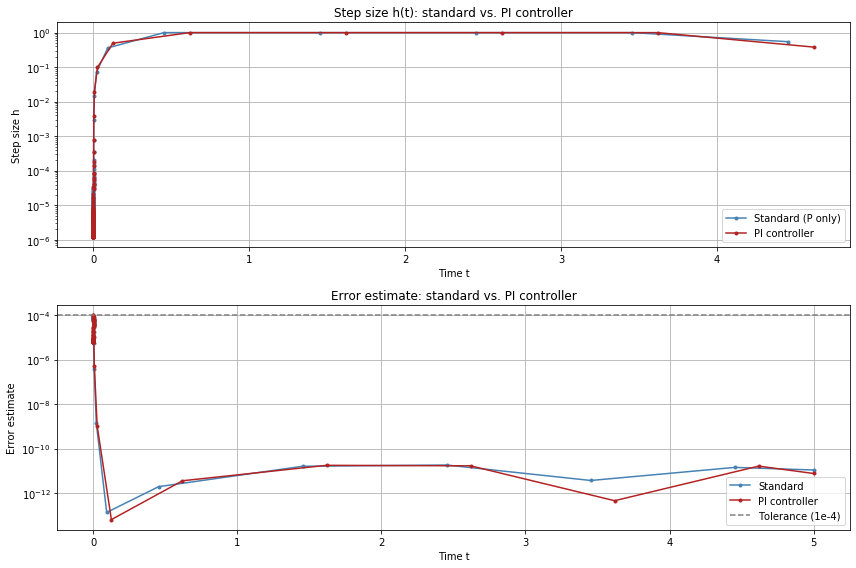

In [40]:
# ── Comparison: standard controller vs. PI controller ────────────────────────

t_std, y_std, h_std, e_std, stats_std = adaptive_solver(1, 0, 5, 0.1, 1e-4)
t_pi,  y_pi,  h_pi,  e_pi,  stats_pi  = adaptive_solver_PI(1, 0, 5, 0.1, 1e-4)

print("=" * 65)
print("BONUS 1: STANDARD vs. PI CONTROLLER")
print("=" * 65)
print(f"{'Metric':<25} {'Standard':<20} {'PI Controller'}")
print("-" * 65)
for label, vs, vp in [
    ("Accepted steps",  stats_std['accepted'],       stats_pi['accepted']),
    ("Rejected steps",  stats_std['rejected'],       stats_pi['rejected']),
    ("Function evals",  stats_std['function_evals'], stats_pi['function_evals']),
    ("NR iterations",   stats_std['iters'],          stats_pi['iters']),
]:
    print(f"{label:<25} {str(vs):<20} {vp}")

print()
print("NOTE: For this ODE the two controllers produce very similar results because")
print("the step size stabilizes quickly once the fast transient decays. The PI")
print("controller's advantage is most visible for ODEs with sustained oscillations")
print("or regions where the error changes rapidly over many steps.")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].semilogy(t_std[:-1], h_std, 'o-', color='steelblue',
                 markersize=3, label='Standard (P only)')
axes[0].semilogy(t_pi[:-1],  h_pi,  'o-', color='firebrick',
                 markersize=3, label='PI controller')
axes[0].set_title("Step size h(t): standard vs. PI controller")
axes[0].set_xlabel("Time t")
axes[0].set_ylabel("Step size h")
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(t_std[1:], e_std, 'o-', color='steelblue',
                 markersize=3, label='Standard')
axes[1].semilogy(t_pi[1:],  e_pi,  'o-', color='firebrick',
                 markersize=3, label='PI controller')
axes[1].axhline(1e-4, linestyle='--', color='gray', label='Tolerance (1e-4)')
axes[1].set_title("Error estimate: standard vs. PI controller")
axes[1].set_xlabel("Time t")
axes[1].set_ylabel("Error estimate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## BONUS 2: EMBEDDED RK2 METHOD FOR ERROR ESTIMATION

Instead of step-doubling (which reuses implicit Euler), we can build a more
principled error estimator using an embedded Runge-Kutta pair.

We use the explicit Euler/Heun (RK2) embedded pair:

$$
k_1 = f(t_n, y_n)
$$

$$
k_2 = f(t_n + h, y_n + h k_1)
$$

$$
y_{\text{Euler}} = y_n + h k_1 \quad (\text{order 1: lower accuracy})
$$

$$
y_{\text{Heun}} = y_n + \frac{h}{2}(k_1 + k_2) \quad (\text{order 2: higher accuracy})
$$

$$
\text{error} = \left| y_{\text{Heun}} - y_{\text{Euler}} \right|
$$

The error estimate costs only 2 function evaluations (\(k_1, k_2\)) per step,
versus 3 Newton-Raphson solves for step-doubling — cheaper per step.

---

### IMPORTANT LIMITATION for this ODE

The system:
$$
\frac{dx}{dt} = -5000x + 0.002\sin(t)
$$

is highly stiff. Explicit methods (including RK2) are only stable when:

$$
h < \frac{2}{5000} \approx 0.0004
$$

This is the same constraint that made forward Euler impractical in Part 2.

This means:

- The RK2 solver must use \(h \ll 0.001\) to remain stable  
- It will require thousands of steps to reach \(t = 5\) vs. ~10 for the implicit solver  
- The "cheaper per step" advantage is completely overwhelmed by the step count  

This is not a failure of the implementation — it is the expected and important result.
It directly illustrates why implicit methods exist: for stiff ODEs, explicit methods
are stability-limited regardless of per-step efficiency.

We cap \(h_{\max} = 0.0003\) to stay safely within the stability region. The comparison
is included to demonstrate this fundamental trade-off.

In [41]:
def rk2_embedded_step(y_n, t_n, h):
    """
    One step of the embedded Euler/Heun (RK2) pair.
    Costs exactly 2 function evaluations (k1 and k2).

    Returns: (y_euler, y_heun, error_estimate)
    """
    k1 = f(t_n, y_n)
    k2 = f(t_n + h, y_n + h * k1)

    y_euler = y_n + h * k1                  # First-order (less accurate)
    y_heun  = y_n + (h / 2) * (k1 + k2)    # Second-order (more accurate)
    error   = abs(y_heun - y_euler)

    return y_euler, y_heun, error


In [42]:
def adaptive_solver_RK2(y0, t0, tf, h0, tol, h_max=0.0003):
    """
    Adaptive solver using the embedded Euler/Heun (RK2) pair.

    h_max is capped at 0.0003 to stay within the explicit stability region
    for this stiff ODE (stability boundary: h < 2/5000 = 0.0004).
    Exceeding this limit causes exponential blow-up regardless of tolerance.

    Returns: (t_array, y_array, h_history, err_history, stats_dict)
    """
    t = [t0]
    y = [y0]
    h = min(h0, h_max)

    h_hist   = []
    err_hist = []

    stats = {
        'accepted':       0,
        'rejected':       0,
        'function_evals': 0,   # Each step costs exactly 2 evals (k1, k2)
    }

    max_steps  = 500000   # Large limit needed, RK2 takes many more steps than implicit
    step_count = 0

    while t[-1] < tf and step_count < max_steps:
        step_count += 1

        y_n = y[-1]
        t_n = t[-1]

        # Cap h at stability limit AND remaining time
        h = min(h, tf - t_n, h_max)
        if h < 1e-14:
            break

        y_euler, y_heun, err = rk2_embedded_step(y_n, t_n, h)
        stats['function_evals'] += 2   # k1 and k2

        # Standard proportional step size update
        if err < 1e-14:
            h_new = 2.0 * h
        else:
            h_new = 0.9 * h * np.sqrt(tol / (err + eps))

        # Enforce stability cap alongside standard bounds
        h_new = max(1e-6, min(h_max, h_new))
        h_new = max(0.2 * h, min(5.0 * h, h_new))

        if err < tol:
            # Accept using the more accurate Heun result
            t.append(t_n + h)
            y.append(y_heun)
            h_hist.append(h)
            err_hist.append(err)
            stats['accepted'] += 1
            h = h_new
        else:
            stats['rejected'] += 1
            h = h_new

        if h < 1e-6:
            print("Warning: minimum step size reached.")
            break

    return np.array(t), np.array(y), h_hist, err_hist, stats

BONUS 2: STEP-DOUBLING (IMPLICIT) vs. EMBEDDED RK2 (EXPLICIT)
Metric                       Implicit (step-doubling)   Explicit (RK2)
----------------------------------------------------------------------
Accepted steps               121                        16824
Rejected steps               7                          3
Function evals               384                        33654
Time points                  122                        16825

The RK2 solver requires orders of magnitude more function evaluations
because stiffness forces h < 0.0004, regardless of the target tolerance.
This demonstrates exactly why implicit methods are essential for stiff ODEs.


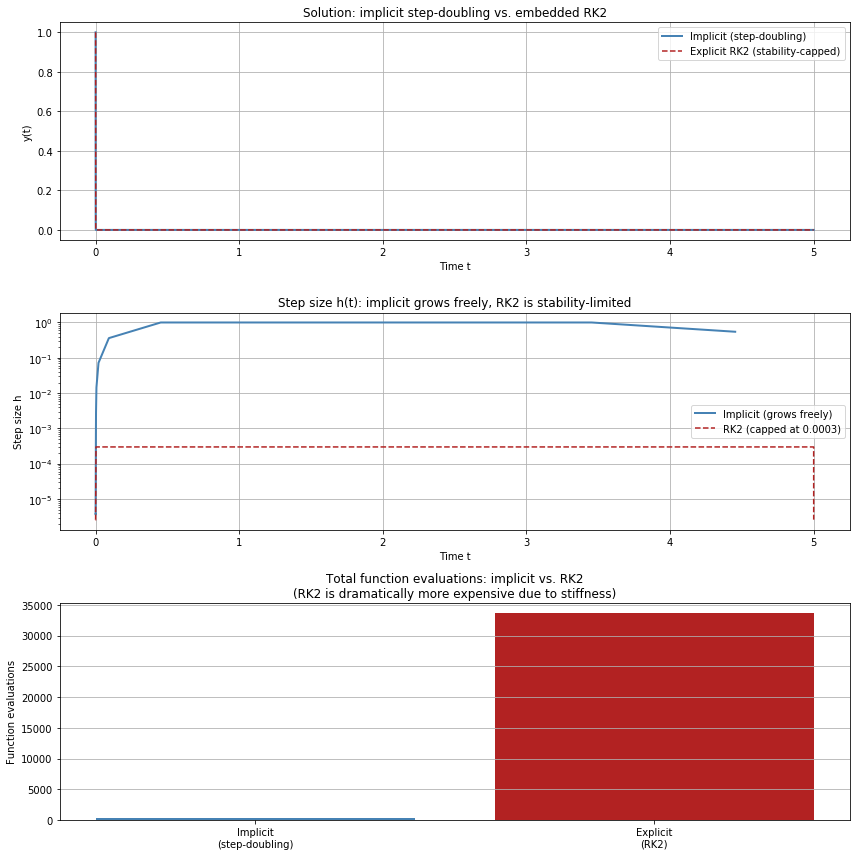

In [43]:
# ── Efficiency comparison: implicit step-doubling vs. explicit RK2 ────────────
#
# The comparison below will show a stark result: the implicit solver completes
# in a handful of steps with large h, while RK2 requires thousands of tiny steps
# due to the stability cap. This is the intended and instructive outcome.
# It confirms that for stiff ODEs, implicit methods are not just preferable
# but necessary for any practical computation.

t_rk2, y_rk2, h_rk2, e_rk2, stats_rk2 = adaptive_solver_RK2(1, 0, 5, 0.0003, 1e-4)
t_imp,  y_imp,  h_imp,  e_imp,  stats_imp  = adaptive_solver(1, 0, 5, 0.1, 1e-4)

print("=" * 65)
print("BONUS 2: STEP-DOUBLING (IMPLICIT) vs. EMBEDDED RK2 (EXPLICIT)")
print("=" * 65)
print(f"{'Metric':<28} {'Implicit (step-doubling)':<26} {'Explicit (RK2)'}")
print("-" * 70)
for label, vi, vr in [
    ("Accepted steps",   stats_imp['accepted'],       stats_rk2['accepted']),
    ("Rejected steps",   stats_imp['rejected'],       stats_rk2['rejected']),
    ("Function evals",   stats_imp['function_evals'], stats_rk2['function_evals']),
    ("Time points",      len(t_imp),                  len(t_rk2)),
]:
    print(f"{label:<28} {str(vi):<26} {vr}")

print()
print("The RK2 solver requires orders of magnitude more function evaluations")
print("because stiffness forces h < 0.0004, regardless of the target tolerance.")
print("This demonstrates exactly why implicit methods are essential for stiff ODEs.")

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Solution comparison
axes[0].plot(t_imp,  y_imp,  '-',  color='steelblue', label='Implicit (step-doubling)', linewidth=2)
axes[0].plot(t_rk2, y_rk2, '--', color='firebrick',  label='Explicit RK2 (stability-capped)', linewidth=1.5)
axes[0].set_title("Solution: implicit step-doubling vs. embedded RK2")
axes[0].set_xlabel("Time t")
axes[0].set_ylabel("y(t)")
axes[0].legend()
axes[0].grid(True)

# Step size comparison. The contrast here is the main result
axes[1].semilogy(t_imp[:-1],  h_imp,  '-',  color='steelblue', label='Implicit (grows freely)', linewidth=2)
axes[1].semilogy(t_rk2[:-1], h_rk2, '--', color='firebrick',  label='RK2 (capped at 0.0003)', linewidth=1.5)
axes[1].set_title("Step size h(t): implicit grows freely, RK2 is stability-limited")
axes[1].set_xlabel("Time t")
axes[1].set_ylabel("Step size h")
axes[1].legend()
axes[1].grid(True)

# Function evaluations bar chart
axes[2].bar(["Implicit\n(step-doubling)", "Explicit\n(RK2)"],
            [stats_imp['function_evals'], stats_rk2['function_evals']],
            color=['steelblue', 'firebrick'])
axes[2].set_title("Total function evaluations: implicit vs. RK2\n"
                  "(RK2 is dramatically more expensive due to stiffness)")
axes[2].set_ylabel("Function evaluations")
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()


## BONUS 3: WORK-PRECISION DIAGRAM

A work-precision diagram is a standard tool used for comparing ODE solvers fairly.
It answers the question: for a given amount of computational work, how accurate is each method?

- **X-axis:** total function evaluations (proxy for computational cost)  
- **Y-axis:** absolute error at $t = 5$ (accuracy)

Each point on a curve corresponds to one tolerance value (adaptive solvers)
or one step size (fixed solver). A curve that sits lower and to the left
is better since it achieves higher accuracy for less work.

We use a very fine fixed-step solve with $h = 10^{-5}$ as a high-accuracy reference
solution, since the exact closed-form solution of this ODE is not used in practice.

---

### NOTE on expected results

Because our ODE is linear and has a very fast transient that dies out at $t \approx 0.01$,
the solution at $t = 5$ is dominated by the near steady-state particular solution.

All methods will achieve similar final accuracy once past the transient.

The work-precision diagram primarily captures the cost of resolving the initial transient
at different tolerances.

In [44]:
# ── High-accuracy reference solution ─────────────────────────────────────────
_, y_ref_arr, _ = fixed_solver(1, 0, 5, 1e-5)
y_ref = y_ref_arr[-1]
print(f"Reference solution at t=5 (h=1e-5): y = {y_ref:.10f}")

Reference solution at t=5 (h=1e-5): y = -0.0000002070


In [45]:
# ── Sweep tolerances for adaptive solvers ────────────────────────────────────
tolerances = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 1e-6]

work_adaptive    = []
error_adaptive   = []
work_adaptive_PI = []
error_adaptive_PI= []

print("\nSweeping tolerances: standard and PI adaptive solvers...")
for tol in tolerances:
    t_w, y_w, _, _, st_w = adaptive_solver(1, 0, 5, 0.1, tol)
    work_adaptive.append(st_w['function_evals'])
    error_adaptive.append(abs(y_w[-1] - y_ref))

    t_p, y_p, _, _, st_p = adaptive_solver_PI(1, 0, 5, 0.1, tol)
    work_adaptive_PI.append(st_p['function_evals'])
    error_adaptive_PI.append(abs(y_p[-1] - y_ref))

    print(f"  tol={tol:.0e}  |  std: evals={st_w['function_evals']:>6}, "
          f"err={abs(y_w[-1]-y_ref):.2e}  |  "
          f"PI:  evals={st_p['function_evals']:>6}, err={abs(y_p[-1]-y_ref):.2e}")


Sweeping tolerances: standard and PI adaptive solvers...
  tol=1e-02  |  std: evals=    21, err=1.77e-07  |  PI:  evals=    21, err=1.77e-07
  tol=5e-03  |  std: evals=    24, err=1.77e-07  |  PI:  evals=    21, err=1.77e-07
  tol=1e-03  |  std: evals=   159, err=1.77e-07  |  PI:  evals=   438, err=1.77e-07
  tol=5e-04  |  std: evals=   198, err=1.77e-07  |  PI:  evals=   675, err=1.77e-07
  tol=1e-04  |  std: evals=   384, err=1.77e-07  |  PI:  evals=  2055, err=1.77e-07
  tol=5e-05  |  std: evals=   522, err=1.77e-07  |  PI:  evals=  2973, err=1.77e-07
  tol=1e-05  |  std: evals=  1107, err=1.77e-07  |  PI:  evals=  4890, err=1.77e-07
  tol=1e-06  |  std: evals=300000, err=1.00e+00  |  PI:  evals=300000, err=1.00e+00


In [46]:
# ── Sweep step sizes for fixed solver ────────────────────────────────────────
h_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005]

work_fixed  = []
error_fixed = []

print("\nSweeping step sizes: fixed solver...")
for h_val in h_values:
    _, y_fx, fe_fx = fixed_solver(1, 0, 5, h_val)
    work_fixed.append(fe_fx)
    error_fixed.append(abs(y_fx[-1] - y_ref))
    print(f"  h={h_val:.4f}  |  evals={fe_fx:>6},  err={abs(y_fx[-1]-y_ref):.2e}")


Sweeping step sizes: fixed solver...
  h=0.1000  |  evals=    50,  err=1.77e-07
  h=0.0500  |  evals=   100,  err=1.77e-07
  h=0.0200  |  evals=   250,  err=1.77e-07
  h=0.0100  |  evals=   500,  err=1.77e-07
  h=0.0050  |  evals=  1000,  err=1.77e-07
  h=0.0020  |  evals=  2500,  err=1.77e-07
  h=0.0010  |  evals=  5000,  err=1.78e-07
  h=0.0005  |  evals= 10000,  err=1.79e-07


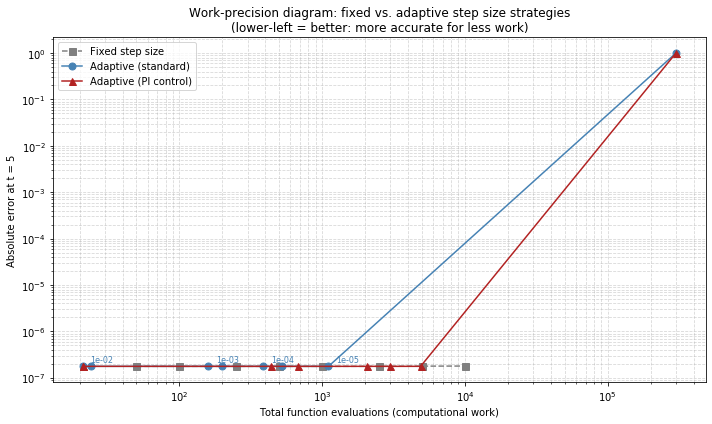

In [47]:
# ── Work-precision plot assisted by Claude for formatting ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(work_fixed,        error_fixed,        's--', color='gray',
          label='Fixed step size', markersize=7)
ax.loglog(work_adaptive,     error_adaptive,     'o-',  color='steelblue',
          label='Adaptive (standard)', markersize=7)
ax.loglog(work_adaptive_PI,  error_adaptive_PI,  '^-',  color='firebrick',
          label='Adaptive (PI control)', markersize=7)

# Annotate every other tolerance on the standard adaptive curve to avoid crowding
for i in range(0, len(tolerances), 2):
    ax.annotate(f'{tolerances[i]:.0e}',
                xy=(work_adaptive[i], error_adaptive[i]),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8, color='steelblue')

ax.set_xlabel("Total function evaluations (computational work)")
ax.set_ylabel("Absolute error at t = 5")
ax.set_title("Work-precision diagram: fixed vs. adaptive step size strategies\n"
             "(lower-left = better: more accurate for less work)")
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("Work-precision summary:")
print(f"{'Tolerance':<12} {'Std evals':<14} {'Std error':<14} {'PI evals':<14} {'PI error'}")
print("-" * 65)
for tol, fe_s, err_s, fe_p, err_p in zip(
        tolerances, work_adaptive, error_adaptive, work_adaptive_PI, error_adaptive_PI):
    print(f"{tol:<12.0e} {fe_s:<14} {err_s:<14.4e} {fe_p:<14} {err_p:.4e}")


Work-precision summary:
Tolerance    Std evals      Std error      PI evals       PI error
-----------------------------------------------------------------
1e-02        21             1.7663e-07     21             1.7663e-07
5e-03        24             1.7664e-07     21             1.7662e-07
1e-03        159            1.7663e-07     438            1.7662e-07
5e-04        198            1.7662e-07     675            1.7663e-07
1e-04        384            1.7663e-07     2055           1.7663e-07
5e-05        522            1.7663e-07     2973           1.7663e-07
1e-05        1107           1.7663e-07     4890           1.7663e-07
1e-06        300000         1.0000e+00     300000         1.0000e+00
